# Question A2 (10 marks)

### In this question, we will determine the optimal learning rate for mini-batch gradient descent. Find the optimal learning rate for mini-batch gradient descent by training the neural network and evaluating the performances for different learning rates. Note: Use 5-fold cross-validation on the training partition to perform hyperparameter selection. You will have to reconsider the scaling of the dataset during the 5-fold cross validation.

#### Plot mean cross-validation accuracies on the final epoch for different learning rates as a scatter plot. Limit search space to learning rates {0.001, 0.005, 0.0001, 0.0005}. Next, create a table of number of epochs required to reach convergence against different learning rates. Finally, select the optimal learning rate and state a reason for your selection.



This might take a while to run, so plan your time carefully.

In [1]:
import tqdm
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

from common_utils import set_seed

1.To reduce repeated code, place your

- network (MLP defined in QA1)

- torch datasets (CustomDataset defined in QA1)
- loss function (loss_fn defined in QA1)
in a separate file called common_utils.py

Import them into this file. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked.

The following code cell will not be marked.

In [3]:
# YOUR CODE HERE
from common_utils import EarlyStopper, loss_fn, MLP, CustomDataset, split_dataset, preprocess_dataset, train_loop, test_loop

no_features = 77
no_hidden = [128, 128, 128]
no_labels = 1
dropout_rate = 0.3

batch_size = 64
learning_rates = [0.001, 0.005, 0.0001, 0.0005]
weight_decay = 0.0005
max_epochs = 200
patience = 5

no_folds = 5

seed = 42

# setting seed
set_seed(seed)

2.Define different folds for different learning rates to get a dictionary of training and validation datasets. Preprocess your datasets accordingly.

In [5]:
def generate_cv_folds_for_learning_rates(parameters, X_train, y_train):
    """
    returns:
    X_train_scaled_dict(dict) where X_train_scaled_dict[learning_rate] is a list of the preprocessed training matrix for the different folds.
    X_val_scaled_dict(dict) where X_val_scaled_dict[learning_rate] is a list of the processed validation matrix for the different folds.
    y_train_dict(dict) where y_train_dict[learning_rate] is a list of labels for the different folds
    y_val_dict(dict) where y_val_dict[learning_rate] is a list of labels for the different folds
    """
    # YOUR CODE HERE
    X_train_scaled_dict = {lr: [] for lr in parameters}
    X_val_scaled_dict = {lr: [] for lr in parameters}
    y_train_dict = {lr: [] for lr in parameters}
    y_val_dict = {lr: [] for lr in parameters}
    
    kf = KFold(n_splits = no_folds, shuffle = True, random_state = seed)
    
    for lr in parameters:
        # For each learning rate, generate (no_folds) folds
        for train_index, validation_index in kf.split(X_train):
            # Split the data
            X_training, X_validation = X_train[train_index], X_train[validation_index]
            y_training, y_validation = y_train[train_index], y_train[validation_index]
            
            # Scale the features separately for each fold
            X_train_scaled_data, X_val_scaled_data = preprocess_dataset(X_training, X_validation)

            # Store in dicts
            X_train_scaled_dict[lr].append(X_train_scaled_data)
            X_val_scaled_dict[lr].append(X_val_scaled_data)
            y_train_dict[lr].append(y_training)
            y_val_dict[lr].append(y_validation)
        
    return X_train_scaled_dict, X_val_scaled_dict, y_train_dict, y_val_dict

In [6]:
df = pd.read_csv('simplified.csv')
df['label'] = df['filename'].str.split('_').str[-2]

X_train, y_train, X_test, y_test = split_dataset(
    df,
    columns_to_drop = ['filename','label'],
    test_size = 0.25,
    random_state = seed
)

X_train_scaled_dict, X_val_scaled_dict, y_train_dict, y_val_dict = generate_cv_folds_for_learning_rates(learning_rates, X_train.to_numpy(), y_train)

3.Perform hyperparameter tuning for the different learning rates with 5-fold cross validation.

In [9]:
# YOUR CODE HERE
def find_optimal_hyperparameter(X_train_scaled_dict, X_val_scaled_dict, y_train_dict, y_val_dict, parameters, parameters_name):
    cross_validation_accuracies = []
    cross_validation_times = []

    for lr in parameters:
        fold_accuracies = []
        fold_epochs = []

        for fold in range(no_folds):
            train_dataset = CustomDataset(X_train_scaled_dict[lr][fold], y_train_dict[lr][fold])
            val_dataset = CustomDataset(X_val_scaled_dict[lr][fold], y_val_dict[lr][fold])

            train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle=False)

            model = MLP(no_features, no_hidden, no_labels, dropout_rate)
            optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay)
            early_stopper = EarlyStopper(patience = patience, min_delta = 0)

            epochs_run = 0

            for epoch in range(max_epochs):
                train_loop(train_loader, model, loss_fn, optimizer)
                val_loss, val_acc = test_loop(val_loader, model, loss_fn)
                epochs_run += 1

                if early_stopper.early_stop(val_loss):
                    break

            fold_accuracies.append(val_acc)
            fold_epochs.append(epochs_run)

        # Average across folds
        cross_validation_accuracies.append(np.mean(fold_accuracies))
        cross_validation_times.append(np.mean(fold_epochs))

    return cross_validation_accuracies, cross_validation_times

cross_validation_accuracies, cross_validation_times = find_optimal_hyperparameter(X_train_scaled_dict, X_val_scaled_dict, y_train_dict, y_val_dict, learning_rates, 'learning_rate')


In [10]:
print("--- Validate the values of arrays ---\n")
print("Cross Validation Accuracies:", cross_validation_accuracies)
print("Cross Validation Times:", cross_validation_times)

--- Validate the values of arrays ---

Cross Validation Accuracies: [0.680270231927873, 0.6104820660708258, 0.6167909836266063, 0.6704296853979855]
Cross Validation Times: [28.2, 17.8, 31.8, 26.2]


4.Plot scatterplot of mean cross validation accuracies for the different learning rates.

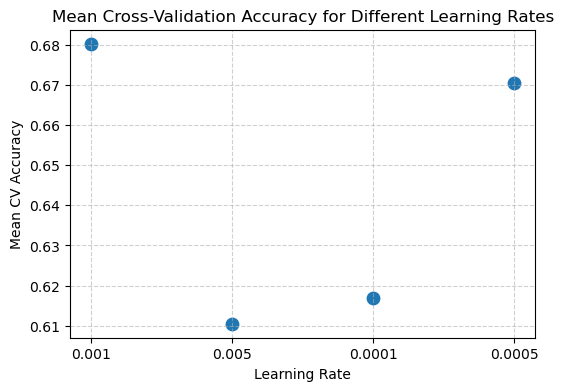

In [12]:
# YOUR CODE HERE
plt.figure(figsize=(6,4))

x_pos = range(len(learning_rates))

plt.scatter(x_pos, cross_validation_accuracies, s = 80)

plt.xticks(x_pos, learning_rates)
plt.xlabel('Learning Rate')
plt.ylabel('Mean CV Accuracy')
plt.title('Mean Cross-Validation Accuracy for Different Learning Rates')

plt.grid(True, linestyle = '--', alpha = 0.6)

plt.show()

4.Create a table of number of epochs required to reach convergence against different learning rates. Select the optimal learning rate and state a reason for your selection.

In [14]:
df = pd.DataFrame({
    'Learning Rate': learning_rates,
    'Number of Epochs Required': cross_validation_times, 
    'Cross Validation Accuracies': cross_validation_accuracies
})

df

,Learning Rate,Number of Epochs Required,Cross Validation Accuracies
0,0.0010,28.2,0.680270
1,0.0050,17.8,0.610482
2,0.0001,31.8,0.616791
3,0.0005,26.2,0.670430


In [16]:
# YOUR CODE HERE
optimal_learning_rate = 0.001
reason = "The scatter plot shows that learning rates 0.005 and 0.0001 perform worse, with mean cross-validation accuracies around 0.61, while 0.001 and 0.0005 achieve higher accuracies above 0.67. Between these two better-performing rates, 0.001 achieves the highest cross-validation accuracy (0.680) and also converges in fewer epochs (28.2) compared to 0.0005, which has slightly lower accuracy and requires more epochs. Therefore, 0.001 is selected as the optimal learning rate because it provides the best balance between model performance and training efficiency."

print("The Optimal Learning Rate: ", optimal_learning_rate)
print("The Reason:\n" + reason)

The Optimal Learning Rate:  0.001
The Reason:
The scatter plot shows that learning rates 0.005 and 0.0001 perform worse, with mean cross-validation accuracies around 0.61, while 0.001 and 0.0005 achieve higher accuracies above 0.67. Between these two better-performing rates, 0.001 achieves the highest cross-validation accuracy (0.680) and also converges in fewer epochs (28.2) compared to 0.0005, which has slightly lower accuracy and requires more epochs. Therefore, 0.001 is selected as the optimal learning rate because it provides the best balance between model performance and training efficiency.
